In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [11]:
# Load datasets
df_deaths = pd.read_csv("smoking_healthcomparison_1924_2023.csv")
df_healthlevel = pd.read_csv("smokers_health_data_kaggle.csv")
df_features = pd.read_csv("features_dataset.csv")
df_ecigarette = pd.read_csv("e_cigarette_prevalence_14_countries.csv")
 #country based datasets
df_smoking = pd.read_csv("Smoking Rate 2025.csv")
df_income = pd.read_csv("Country-Income-and-Education-Level.csv")
df_expenditure= pd.read_csv("annual-healthcare-expenditure.csv")
df_globalhealth = pd.read_csv("Bloomberg Global Health Index_DP.csv")
df_obesitiy = pd.read_csv("obesity_country.csv")
df_mortality = pd.read_csv("mortality_bycountry.csv")
df_airQ = pd.read_csv("airQ_deaths.csv")


#Data Cleaning/ Processing

In [12]:
# Cleaning the data related to death trends
df_deaths = pd.read_csv("smoking_healthcomparison_1924_2023.csv")
columns_to_drop = ['City', 'Anti_Smoking_Campaigns', 'Legislation_Strength']
df_cleaned_deaths = df_deaths.drop(columns=columns_to_drop)

df_cleaned_deaths = df_cleaned_deaths.rename(columns={
    'Male_Smokers_Percentage': 'Male',
    'Female_Smokers_Percentage': 'Female',
    'Smoking_Related_Deaths': 'Deaths',
    'Youth_Smokers_Percentage': 'Youth',
    'Average_Cigarettes_Per_Day': 'Daily average'})
#print(df_cleaned_deaths.head())

# Cleaning the data related to health metrics
df_healthlevel['systolic_bp'] = df_healthlevel['blood_pressure'].str.split('/').str[0].astype(float)
df_healthlevel['current_smoker'] = df_healthlevel['current_smoker'].replace({
    'yes': 'smoker',
    'no': 'not smoker'})

df_clean_healthlevel= df_healthlevel
#print(df_clean_healthlevel.head())

# Cleaning the data related to features of smokers'
df_features = pd.read_csv("features_dataset.csv")
columns_to_keep = [
    'weight(kg)', 
    'fasting blood sugar', 
    'triglyceride', 
    'HDL', 
    'LDL', 
    'hemoglobin', 
    'serum creatinine']

df_cleaned_features = df_features[columns_to_keep]
#print(df_cleaned_features.head())

# Cleaning the data related to e-cigarette usage
df_ecigarette = pd.read_csv("e_cigarette_prevalence_14_countries.csv")
df_cleaned_EC = df_ecigarette.rename(columns={
    'Awareness_Prevalence_%': '%Awareness',
    'Ever_Use_Prevalence_%': '%Used ever',
    'Current_Use_Prevalence_%': '%Current use'})
#print(df_cleaned_EC.head())

# Cleaning the data related to income levels of countries
df_clean_income = df_income.dropna(subset=['Education Index'])
#print(df_clean_income.head())

# Cleaning the data related to countries' healthcare expenditure levels
df_expenditure= pd.read_csv("annual-healthcare-expenditure.csv")
df_cleaned_expenditure = df_expenditure.rename(columns={
    'Current health expenditure per capita, PPP (current international $)': 'current healthcare expenditure'})
#print(df_cleaned_expenditure.head())

#Cleaning the obesity rate data
data = df_obesitiy.iloc[3:].copy()
data.rename(columns={'Unnamed: 0': 'Country'}, inplace=True)
    # Function to extract the numerical value from strings
def extract_value(val):
    try:
        if pd.isna(val) or val == 'No data':
            return None
        return float(val.split('[')[0].strip())
    except:
        return None
    
both_sexes_cols = [col for col in data.columns if '.' not in col and col != 'Country']
years = sorted([int(c) for c in both_sexes_cols])
both_sexes_cols_sorted = [str(y) for y in years]

for col in both_sexes_cols:
    data[col] = data[col].apply(extract_value)
data.dropna    
#print(data.head())

# Cleaning the data related to mortality by country
df_mortality = pd.read_csv("mortality_bycountry.csv")
columns_to_drop2 = ['Unnamed: 0','DateModified', 'Sex']
df_cleaned_mortality = df_mortality.drop(columns=columns_to_drop2)
#print(df_cleaned_mortality.head())


Explatory Data Analysis

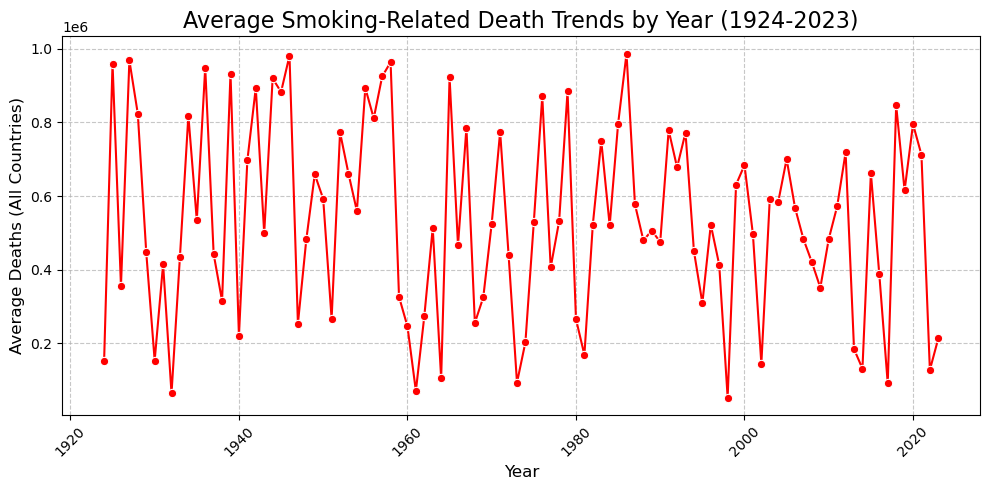

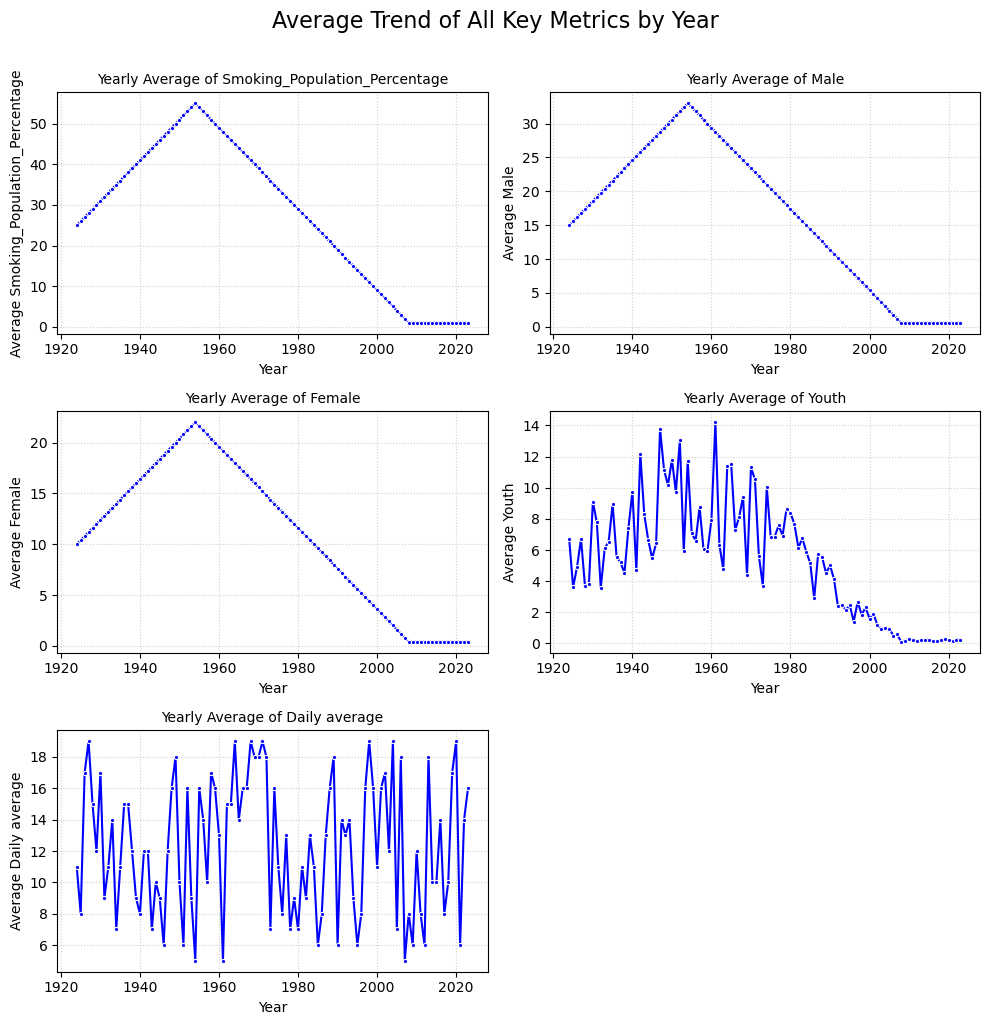

In [13]:
# Taking yearly averages because I want to handle a total value of all countries
df_yearly_average = df_cleaned_deaths.groupby('Year').mean(numeric_only=True).reset_index()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df_yearly_average,
    x='Year',
    y='Deaths',
    color='red',
    marker='o' # show points
)

plt.title('Average Smoking-Related Death Trends by Year (1924-2023)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Deaths (All Countries)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Choose other metrices to plot seperately
columns_to_plot = [
    'Smoking_Population_Percentage',
    'Male',
    'Female',
    'Youth',
    'Daily average']
num_cols = len(columns_to_plot)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
axes = axes.flatten() 

for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    sns.lineplot(data=df_yearly_average, x='Year', y=col, ax=ax, color='blue', marker='.')
    ax.set_title(f'Yearly Average of {col}', fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel(f'Average {col}')
    ax.grid(True, linestyle=':', alpha=0.6)

fig.delaxes(axes[num_cols])

plt.suptitle('Average Trend of All Key Metrics by Year', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1.01])
plt.show() # plotting

H0:There has been no significant change in the number of deaths caused by smoking over the years.                                                    
H1:The number of deaths caused by smoking tend to increase year by year.

Analysis:                                               
There are very sharp fluctuations between 1920 and 1960.                                                    
After 1990, it seems that the peaks have been gradually decreasing.


C:\Users\komse\AppData\Local\Temp\ipykernel_21692\3625598340.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\komse\AppData\Local\Temp\ipykernel_21692\3625598340.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['smoker', 'not smoker'])
C:\Users\komse\AppData\Local\Temp\ipykernel_21692\3625598340.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\komse\AppData\Local\Temp\ipykernel_21692\3625598340.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabel

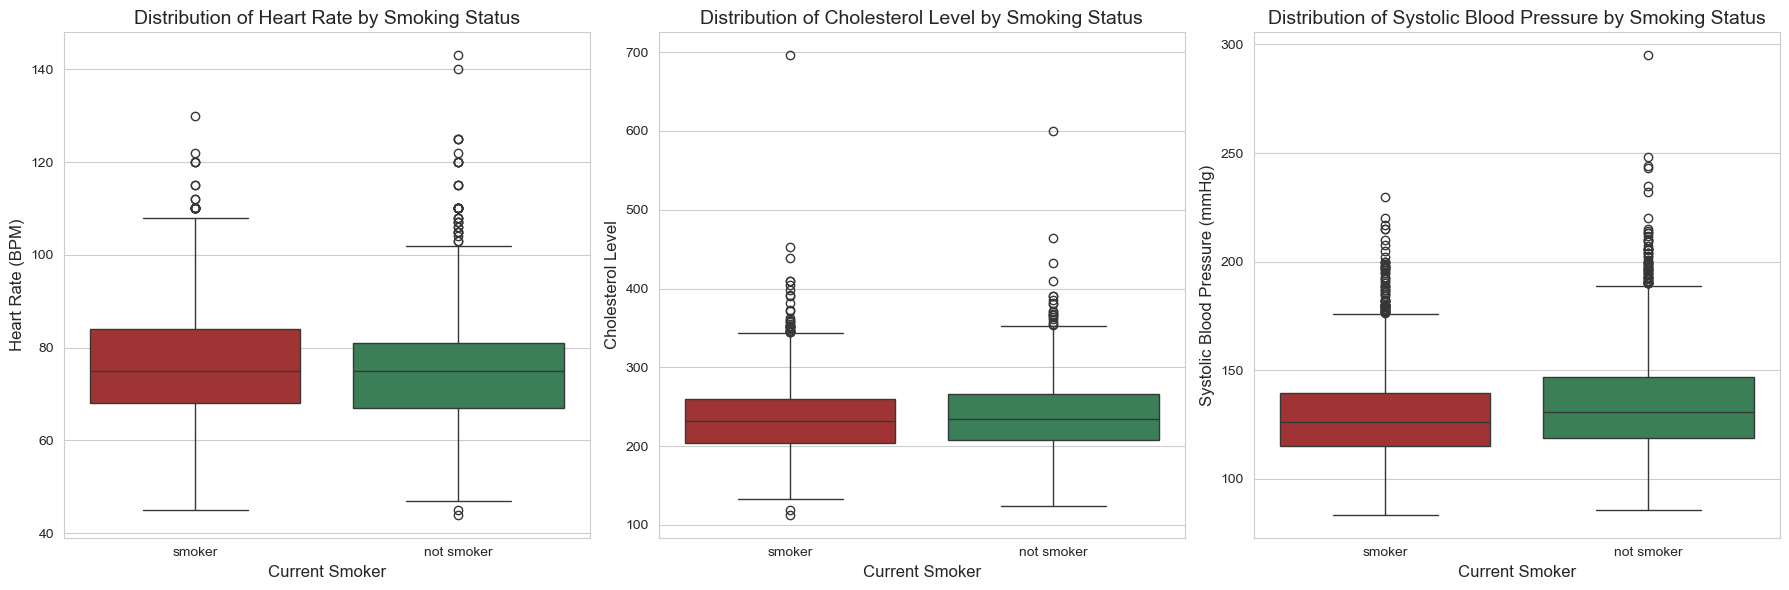

In [14]:
# Setting a style for better visualization
sns.set_style("whitegrid")

# Dropping rows which has missing values in them
cols_to_plot = ['current_smoker', 'heart_rate', 'chol', 'systolic_bp']
df_clean_healthlevel = df_clean_healthlevel[cols_to_plot].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('heart_rate', 'Heart Rate (BPM)', 'Distribution of Heart Rate by Smoking Status'),
    ('chol', 'Cholesterol Level', 'Distribution of Cholesterol Level by Smoking Status'),
    ('systolic_bp', 'Systolic Blood Pressure (mmHg)', 'Distribution of Systolic Blood Pressure by Smoking Status')
]

palette = {'smoker': 'firebrick', 'not smoker': 'seagreen'}

# Box plots
for i, (col, y_label, title) in enumerate(metrics):
    sns.boxplot(
        x='current_smoker',
        y=col,
        data=df_clean_healthlevel,
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel('Current Smoker', fontsize=12)
    axes[i].set_ylabel(y_label, fontsize=12)
    axes[i].set_xticklabels(['smoker', 'not smoker'])

plt.tight_layout()
plt.show()

H0:There is no significant difference in the average heart rate, cholestrol and systolic blood pressure level between people who smoke and who don't.                                                    
H1:In smokers heart rate level, cholesterol level and systolic blood pressure level are expected to be significantly different from not smokers.

Analysis:                                               
1. The center line of the red box in the "smoker" group is slightly higher than the center line of the green box in the "not smoker" group. This indicates that the median heart rate of the smoker group is higher than that of the non-smoker group. Also, the upper limit of the smoker box (3rd quartile) extends higher, meaning higher heart rate values ​​are more common in this group.                                                    
2. For cholesterol level center line of both boxes are more or less the same, there is no big difference in this aspect.                                                    
3. It is obvious that Interquartile range and median level is different for red and green box plots.So, smoking significantly affects the systolic blood pressure level in humans.



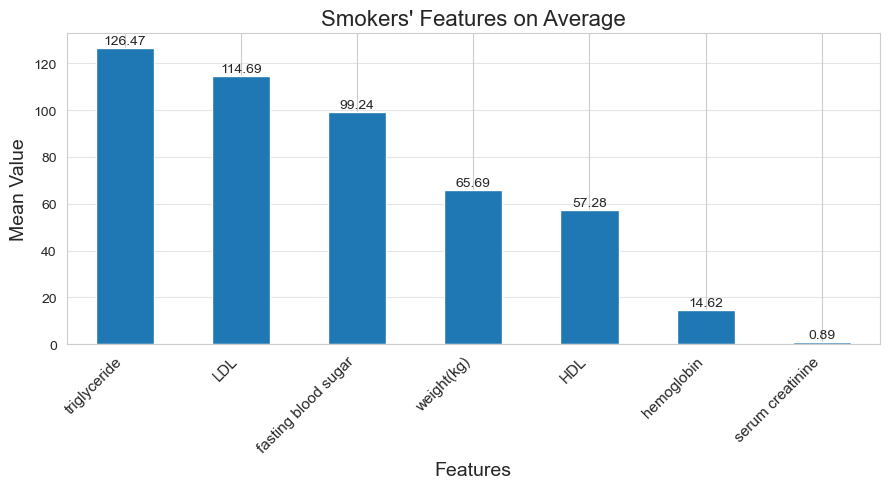

In [15]:
df_cleaned_features = df_features[columns_to_keep].copy()
mean_values = df_cleaned_features.mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))

# Plotting sorted mean values
bars = mean_values.plot(kind='bar', color='#1f77b4')

plt.title("Smokers' Features on Average", fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Mean Value', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11) 

# Adding average values on top of bars
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, 
             f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.grid(axis='y', alpha=0.5)
plt.show()

H0:There is no significant difference between the average values and ideal values of observed metrics for smokers.                                                    
H1:Average values of the observed metrics for smokers are higher than the ideal values for a human body.

Analysis:                                               
1. Fasting Blood Sugar (99.24 mg/dL).
Normal fasting blood sugar is between 70-100 mg/dL (according to my search). 100-125 is considered prediabetes (latent diabetes). The average for smokers is right on the borderline.                                                   
2. LDL - Bad Cholesterol (114.69 mg/dL)
The ideal level is below 100 mg/dL. 100-129 is considered "near ideal". The average for smokers is borderline, which may slightly increase the risk of heart disease.                                                   
3. Other metrics seem to have "normal" mean values. There is nothing going on.


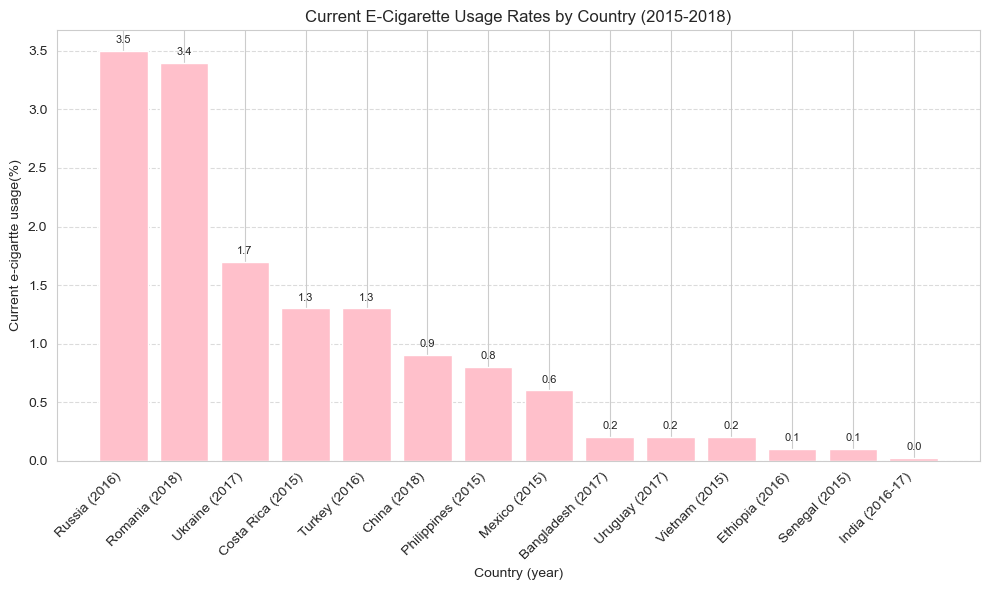

In [16]:
df_sorted = df_cleaned_EC.sort_values(by='%Current use', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(df_sorted['Country_Year'], df_sorted['%Current use'], color='pink')

plt.xlabel("Country (year)")
plt.ylabel("Current e-cigartte usage(%)")
plt.title("Current E-Cigarette Usage Rates by Country (2015-2018)")
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.1f}', ha='center', va='bottom', fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

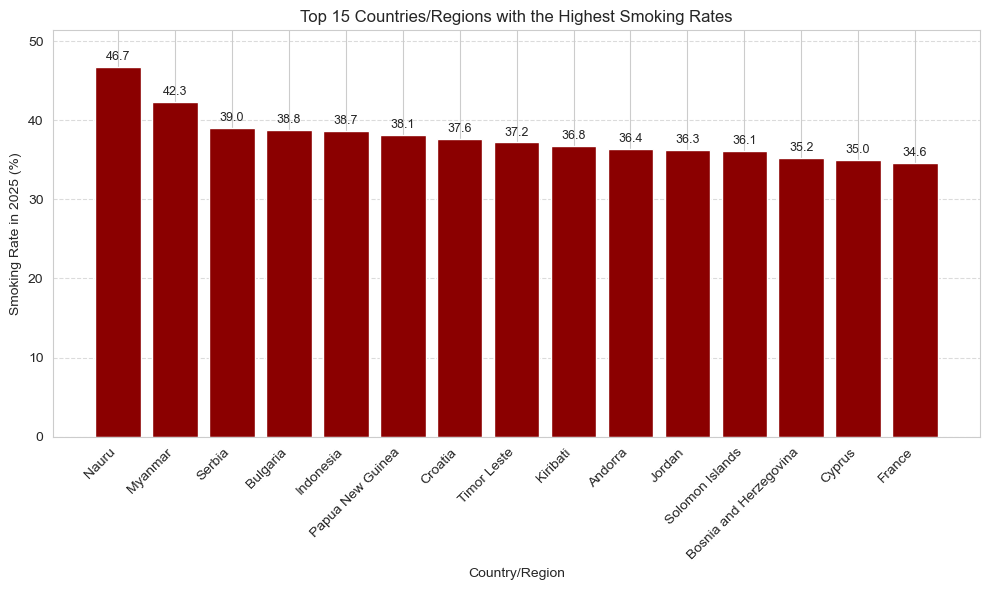

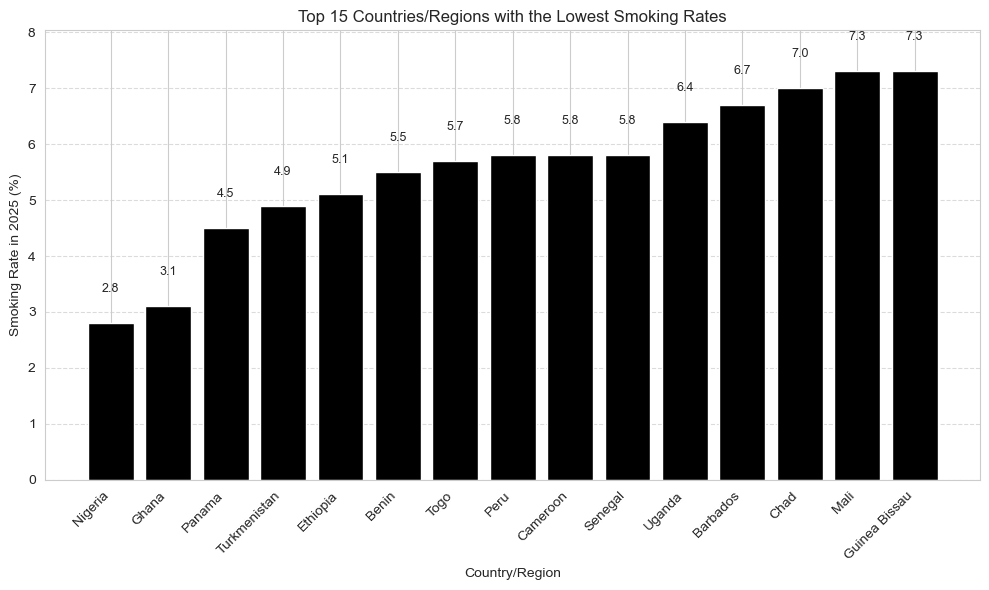

In [17]:
#PLotting top 15 countries by their smoking ratings
df_top_15 = df_smoking.head(15)

plt.figure(figsize=(10, 6))
bars = plt.bar(df_top_15['Region'], df_top_15['Smoking Rate 2025'], color='darkred')

plt.xlabel("Country/Region")
plt.ylabel("Smoking Rate in 2025 (%)")
plt.title("Top 15 Countries/Regions with the Highest Smoking Rates")
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}', ha='center', va='bottom', fontsize=9)

plt.ylim(0, df_top_15['Smoking Rate 2025'].max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

#PLotting 15 countries with lowest smoking ratings

df_low_15 = df_smoking.sort_values(by='Smoking Rate 2025', ascending=True)
df_low_15 = df_low_15.head(15)

plt.figure(figsize=(10, 6))
bars = plt.bar(df_low_15['Region'], df_low_15['Smoking Rate 2025'], color='black')

plt.xlabel("Country/Region")
plt.ylabel("Smoking Rate in 2025 (%)")
plt.title("Top 15 Countries/Regions with the Lowest Smoking Rates")
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}', ha='center', va='bottom', fontsize=9)

plt.ylim(0, df_low_15['Smoking Rate 2025'].max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

These are just important country based observations that will be used to interpret hypothesis in the following datasets and their related hsitograms.

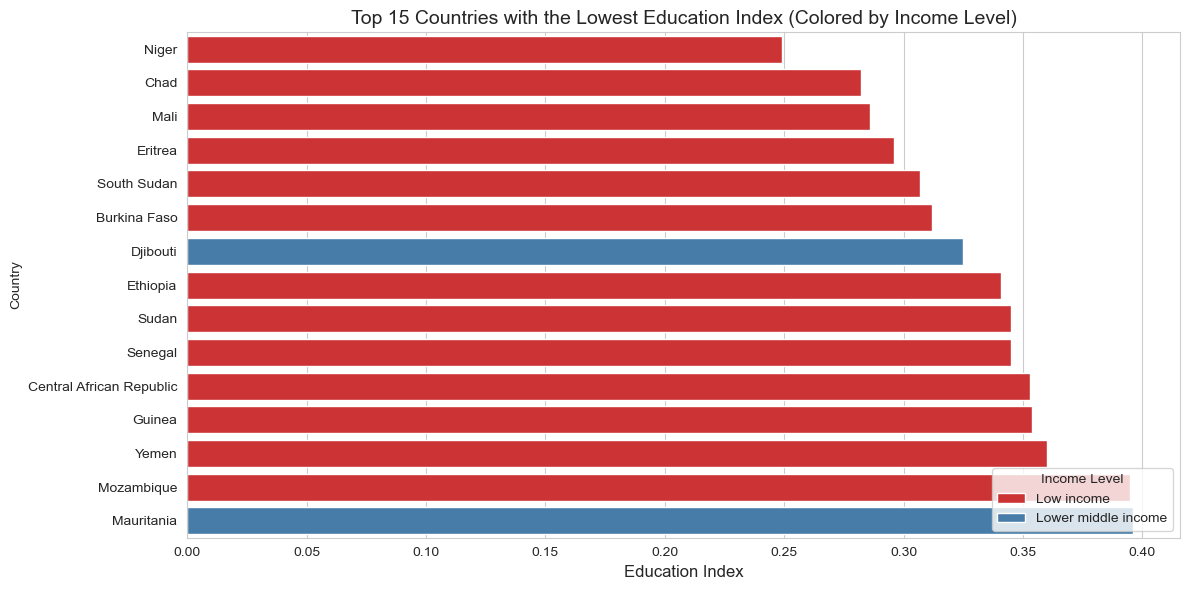

In [18]:
# Sorting from lowest education level to highest
df_sorted = df_clean_income.sort_values(by='Education Index', ascending=True)

# Choosing first 15 countries with low education index
top_15_lowest = df_sorted.head(15)

income_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
color_scheme = ['#984ea3', '#4daf4a', '#377eb8', '#e41a1c'] # Mor, Yeşil, Mavi, Kırmızı
color_map = dict(zip(income_order, color_scheme))

# Arrange countries
country_order = top_15_lowest['Country'].tolist()

plt.figure(figsize=(12, 6))
# Horizontal Bar Plot
sns.barplot(
    data=top_15_lowest,
    x='Education Index', 
    y='Country',         
    hue='Income',       
    palette=color_map,  
    order=country_order, 
    dodge=False        
)

plt.title('Top 15 Countries with the Lowest Education Index (Colored by Income Level)', fontsize=14)
plt.xlabel('Education Index', fontsize=12)
plt.ylabel('Country', fontsize=10)

# Adjusting the legend
plt.legend(title='Income Level', loc='lower right')

plt.tight_layout()
plt.show()


H0:There is no relationship between low education index and smoking prevalence of a country.                                                    
H1:Less educated countries display a tendency for smoking more OR less educated countries display a tendency for smoking less.

Analysis:                                               
In top 15 we mostly see African countries. However, top smoker countries are composed of Europian, Asian and some island states. It seems like it is not appropriate to say "Less educated countries smoke more."                                                    
On the contrary, if we look at the second histogram ("Top 15 Countries/Regions with the Lowest Smoking Rates") we see some common countries. For example: Nigeria, Ethiopia, Senegal, Chad, Mali, Guinea are countries with low education level and also have small smoking percentages. It is possible that there is a relationship between low education level and low smoking rate. H1 is true.                                                   



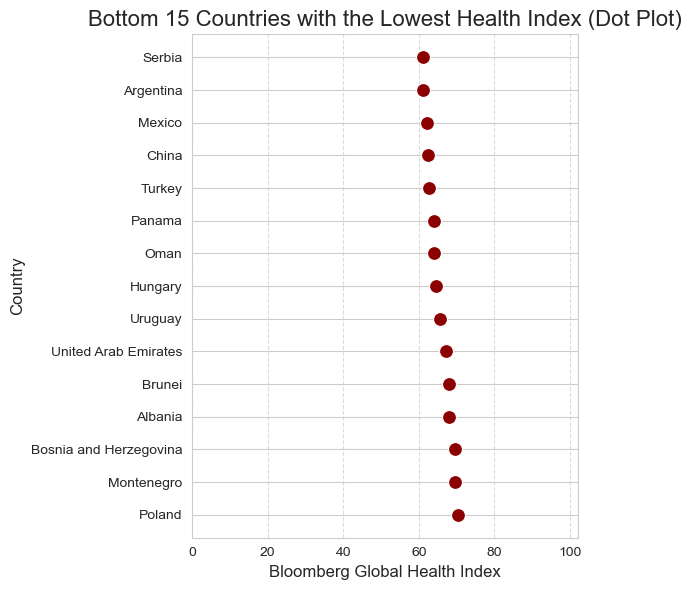

In [19]:
# Sorting the data by the index value in descending order.
top_15= df_globalhealth.sort_values(by='Bloomberg Global Health Index', ascending=True)

plt.figure(figsize=(6, 6))

# Creating a dot plot using seaborn's scatterplot function
sns.scatterplot(
    data=top_15.head(15),
    x='Bloomberg Global Health Index',
    y='Region',
    s=100, # Marker size (dots)
    color='darkred'
)

plt.title('Bottom 15 Countries with the Lowest Health Index (Dot Plot)', fontsize=16)
plt.xlabel('Bloomberg Global Health Index', fontsize=12)
plt.ylabel('Country', fontsize=12)

# X-axis limit
plt.xlim(0, top_15['Bloomberg Global Health Index'].max() * 1.1)

# Adding grid lines for better value readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

H0:There is no relationship between health index and smoking rate for a country.                                                    
H1:Countries which smoke more have lower health indexes.

Analysis:                                               
When we compare the above histogram with the "Top 15 Countries/Regions with the Highest Smoking Rates", Serbia and Bosnia and Herzegovina are common. We need to have further information like p-value to completely be sure about rejecting H0.                                                   



<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
C:\Users\komse\AppData\Local\Temp\ipykernel_21692\3437939503.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Mean PM Concentration ($\mu g/m^3$)', fontsize=12)


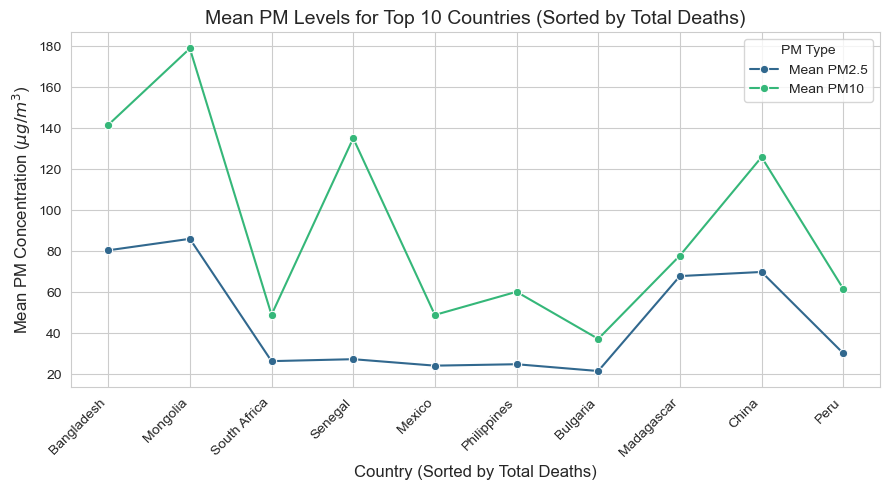

In [20]:
# Aggregate the data by country
agg_df = df_airQ.groupby('Country').agg(
    PM2_5_Mean=('PM2.5', 'mean'),
    PM10_Mean=('PM10', 'mean'),
    TotalDeaths_Sum=('TotalDeaths', 'sum'),
    PMDeaths_Sum=('PMDeaths', 'sum')
).reset_index()

# Sort by Total Deaths and get the top 10 countries
top_10_deaths = agg_df.sort_values(by='TotalDeaths_Sum', ascending=False).head(10)

# Define the country order for the X-axis
country_order = top_10_deaths.sort_values('TotalDeaths_Sum', ascending=False)['Country'].tolist()

# Melt the DataFrame for plotting PM2.5 and PM10
melted_pms = top_10_deaths.melt(
    id_vars='Country',
    value_vars=['PM2_5_Mean', 'PM10_Mean'],
    var_name='PMType',
    value_name='PM_Concentration'
)

# Renaming
melted_pms['PMType'] = melted_pms['PMType'].replace({
    'PM2_5_Mean': 'Mean PM2.5',
    'PM10_Mean': 'Mean PM10'
})

# Convert 'Country' to a categorical type
melted_pms['Country'] = pd.Categorical(melted_pms['Country'], categories=country_order, ordered=True)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=melted_pms,
    x='Country',
    y='PM_Concentration',
    hue='PMType',
    marker='o', # Add markers to emphasize individual data points
    palette='viridis'
)

plt.title('Mean PM Levels for Top 10 Countries (Sorted by Total Deaths)', fontsize=14)
plt.xlabel('Country (Sorted by Total Deaths)', fontsize=12)
plt.ylabel('Mean PM Concentration ($\mu g/m^3$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='PM Type')
plt.tight_layout()


<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
C:\Users\komse\AppData\Local\Temp\ipykernel_21692\3420330506.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Mean PM Concentration ($\mu g/m^3$)', fontsize=12)


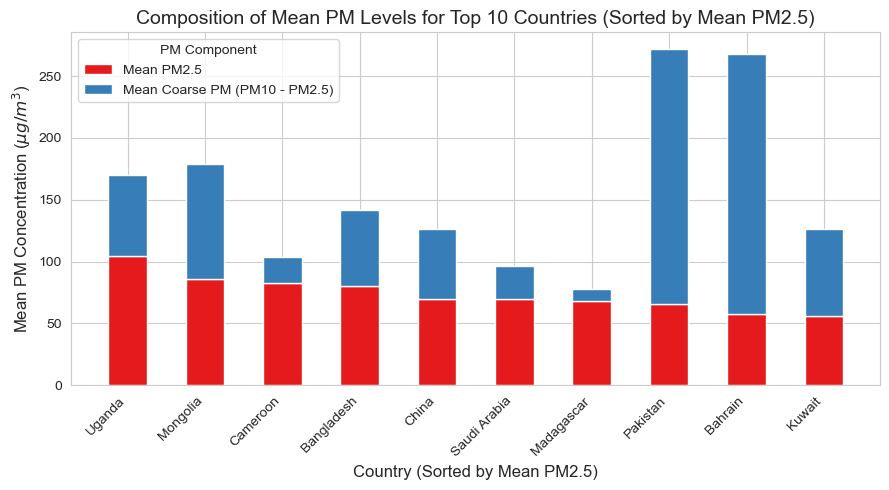

In [21]:
agg_df = df_airQ.groupby('Country').agg(
    PM2_5_Mean=('PM2.5', 'mean'),
    PM10_Mean=('PM10', 'mean')
).reset_index()

agg_df['Coarse_PM_Mean'] = agg_df['PM10_Mean'] - agg_df['PM2_5_Mean']
agg_df['Coarse_PM_Mean'] = agg_df['Coarse_PM_Mean'].clip(lower=0)

# Sorting by PM2_5_Mean and getting the top 10 countries
top_10_pms_stacked = agg_df.sort_values(by='PM2_5_Mean', ascending=False).head(10)
country_order_pm = top_10_pms_stacked['Country'].tolist()
fig, ax = plt.subplots(figsize=(9, 5))

bar_width = 0.5
x = np.arange(len(country_order_pm))

# PM2.5 (the base layer)
ax.bar(
    x,
    top_10_pms_stacked['PM2_5_Mean'],
    bar_width,
    label='Mean PM2.5',
    color='#e41a1c' )

# Coarse PM (stacked on top of PM2.5)
ax.bar(
    x,
    top_10_pms_stacked['Coarse_PM_Mean'],
    bar_width,
    bottom=top_10_pms_stacked['PM2_5_Mean'],
    label='Mean Coarse PM (PM10 - PM2.5)',
    color='#377eb8' )

ax.set_title('Composition of Mean PM Levels for Top 10 Countries (Sorted by Mean PM2.5)', fontsize=14)
ax.set_xlabel('Country (Sorted by Mean PM2.5)', fontsize=12)
ax.set_ylabel('Mean PM Concentration ($\mu g/m^3$)', fontsize=12)


ax.set_xticks(x)
ax.set_xticklabels(country_order_pm, rotation=45, ha='right')
ax.legend(title='PM Component')
plt.tight_layout()

H0:There is no relationship air pollution level and smoking rate for a country.                                                    
H1:Smoking status of a country have an effect on that country's air pollution level.

Analysis:                                               
There is definetly a connection between a country's air quality and total death rate according to the 2 histograms above. But there is not enough information to claim countries with higher smoking rates have more polluted air. We cannot reject H0.                                                   



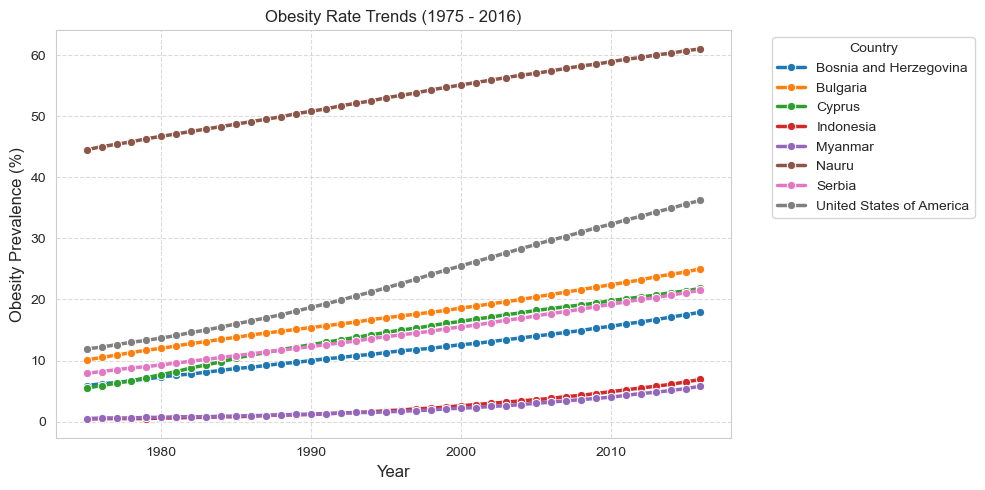

In [22]:
# Visualization of Obesity trends over time
selected_countries = ['Bulgaria', 'United States of America', 'Cyprus', 'Bosnia and Herzegovina', 'Indonesia', 'Nauru', 'Serbia', 'Myanmar']
trend_data = data[data['Country'].isin(selected_countries)]

melted_trend = trend_data.melt(id_vars='Country', value_vars=both_sexes_cols_sorted, var_name='Year', value_name='ObesityRate')
melted_trend['Year'] = melted_trend['Year'].astype(int)

plt.figure(figsize=(10, 5))
sns.lineplot(data=melted_trend, x='Year', y='ObesityRate', hue='Country', marker='o', linewidth=2.5)
plt.title('Obesity Rate Trends (1975 - 2016)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Obesity Prevalence (%)', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

H0:There is no relationship between obesity level and smoking rate for a country.                                                    
H1:A country with higher smoking rate is placed higher up on obesity prevalence graph.

Analysis:                                               
The most obese country is Nauru and it also the the country with the highest smoking rate. When we look at obesity levels of some other countries from top 15 smoker countries, it is seen that most of them have high obesity prevalences (above %20). Because the global average for adult obesity is around 16% (2022 WHO data). Countries with rates above this average are classified as having a "high prevalence".                                                  



(-1.099998535727643,
 1.0999999249989385,
 -1.0999988453551617,
 1.0999992192706194)

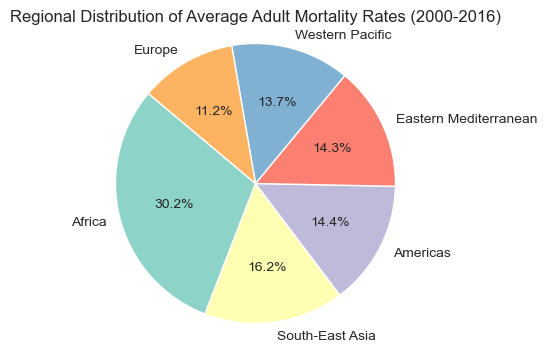

In [23]:
region_avg = df_cleaned_mortality.groupby('ParentLocation')['Adult mortality rate'].mean().sort_values(ascending=False)

#Create a pie chart
plt.figure(figsize=(6, 4))
plt.pie(region_avg, 
        labels=region_avg.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Set3.colors)

plt.title('Regional Distribution of Average Adult Mortality Rates (2000-2016)')
plt.axis('equal')  

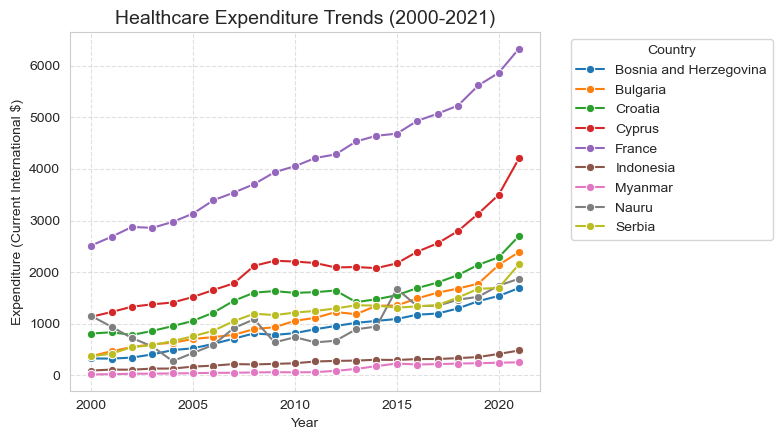

In [24]:
df_cleaned_expenditure = df_expenditure.rename(columns={
    'country ': 'country',
    'Current health expenditure per capita, PPP (current international $)': 'current healthcare expenditure'})
#Selecting countries with high smoking rates
selected_countries = ['Bulgaria', 'Cyprus', 'Bosnia and Herzegovina', 'Indonesia', 'Nauru', 'Serbia', 'Myanmar', 'France', 'Croatia']
df_trends = df_cleaned_expenditure[df_cleaned_expenditure['country'].isin(selected_countries)]

plt.figure(figsize=(8, 4.5))
sns.lineplot(data=df_trends, x='Year', y='current healthcare expenditure', hue='country', marker='o')

plt.title('Healthcare Expenditure Trends (2000-2021)', fontsize=14)
plt.ylabel('Expenditure (Current International $)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


H0:Smoking percentage has no significant impact on healthcare expenditures of a country.                                                    
H1:There is a positive realtionship between a country's smoking percentage and its expenditures on healthcare.

Analysis:                                               
The graph shows that mostly France and Cyprus have sharply increasing expenditures on health. Other highly smoker countries like Croatia, Bulgaria, Serbia are one of the countries that have higher expenditure levels. There is a relationship between smoking level and amount of dollars spent on health in a country.                                                   



Machine Learning Methods

This will bring the project's results to a predictive dimension.

In [25]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Can we predict the death rates in upcoming years (after 2024) by looking at the results of our data: "smoking_healthcomparison_1924_2023.csv" ?

c:\Users\komse\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\komse\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\komse\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


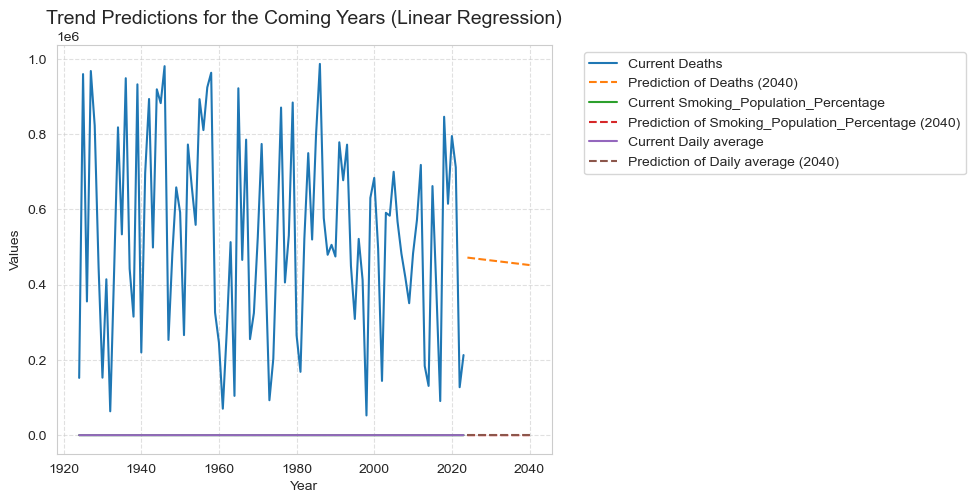

In [69]:
# Target columns to predict
targets = ['Deaths', 'Smoking_Population_Percentage', 'Daily average']

# Upcoming years (from 2024 to 2040)
future_years = np.array(range(2024, 2041)).reshape(-1, 1)
X_current = df_yearly_average[['Year']] 

plt.figure(figsize=(10, 5))

for target in targets:
    model = LinearRegression()
    model.fit(X_current, df_yearly_average[target])
    y_pred_train = model.predict(X_current)
    r2_death = r2_score(df_yearly_average[target], y_pred_train)
    
    # Prediction
    future_preds = model.predict(future_years)

    plt.plot(df_yearly_average['Year'], df_yearly_average[target], label=f'Current {target}')
    plt.plot(range(2024, 2041), future_preds, '--', label=f'Prediction of {target} (2040)')

plt.title('Trend Predictions for the Coming Years (Linear Regression)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Values')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Is it possible to make an assumption for years after 2016 about Obesity Rate Trends? By looking at "obesity_country.csv" ?

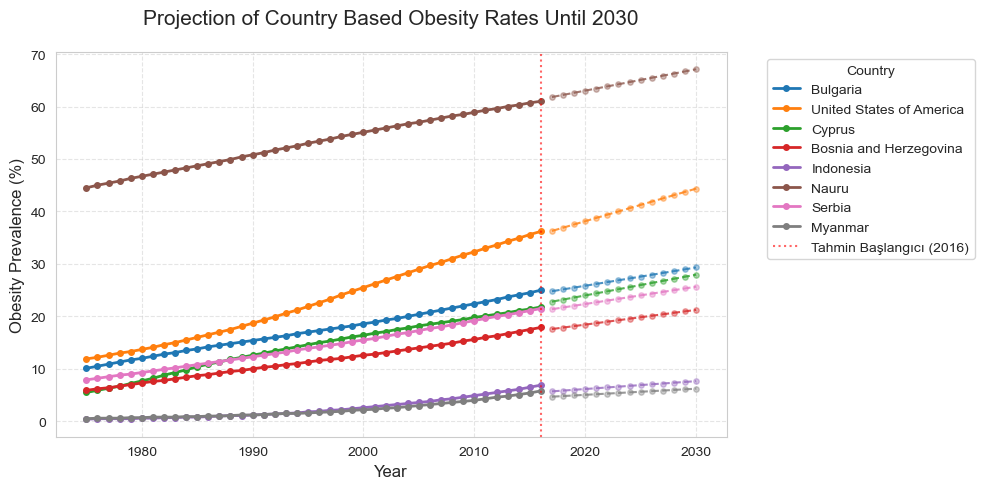

In [59]:
#Continuing with the dataset I have already cleaned at the begining
both_sexes_cols = [col for col in data.columns if '.' not in col and col != 'Country']
years = sorted([int(c) for c in both_sexes_cols])
both_sexes_cols_sorted = [str(y) for y in years]

# Years to 
selected_countries = ['Bulgaria', 'United States of America', 'Cyprus', 'Bosnia and Herzegovina', 'Indonesia', 'Nauru', 'Serbia', 'Myanmar']
future_years = np.array(range(2017, 2031)).reshape(-1, 1)

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

# Machine Learning Model
for country in selected_countries:
    country_data = data[data['Country'] == country]
    X = np.array(years).reshape(-1, 1) 
    y = country_data[both_sexes_cols_sorted].values.flatten() 
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred_train = model.predict(X)
    r2_obesity = r2_score(y, y_pred_train)
    future_preds = model.predict(future_years)
    
    line = plt.plot(years, y, marker='o', markersize=4, label=country, linewidth=2)
    current_color = line[0].get_color()
    
    #Plotting the prediction line
    plt.plot(range(2017, 2031), future_preds, linestyle='--', color=current_color, alpha=0.8)
    plt.scatter(range(2017, 2031), future_preds, color=current_color, s=15, alpha=0.4)

plt.axvline(x=2016, color='red', linestyle=':', alpha=0.6, label='Tahmin Başlangıcı (2016)')
plt.title('Projection of Country Based Obesity Rates Until 2030', fontsize=15, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Obesity Prevalence (%)', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [64]:
r2_obesity

0.9015553127992556

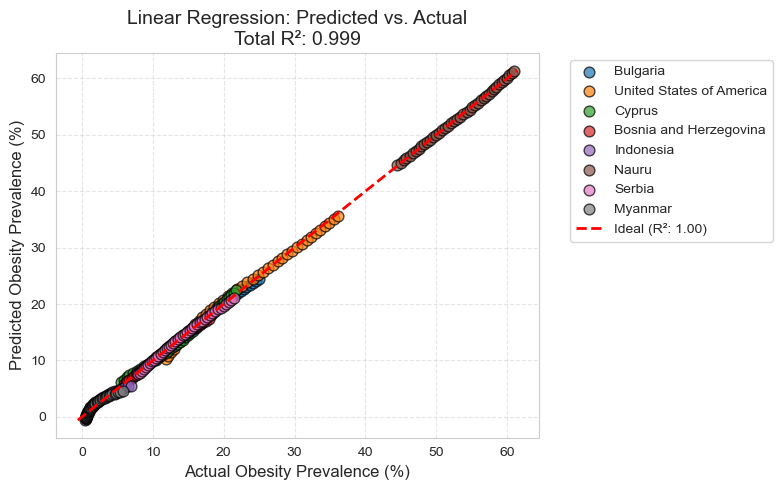

In [66]:
#Plotting the associated R2 value and best fit line
plt.figure(figsize=(8, 5))
all_actual = []
all_predicted = []

for country in selected_countries:
    country_data = data[data['Country'] == country]
    X = np.array(years).reshape(-1, 1)
    y = country_data[both_sexes_cols_sorted].values.flatten()
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    all_actual.extend(y)
    all_predicted.extend(y_pred)
    
    plt.scatter(y, y_pred, alpha=0.7, s=60, edgecolors='black', label=country)

total_r2 = r2_score(all_actual, all_predicted)
min_val = min(min(all_actual), min(all_predicted))
max_val = max(max(all_actual), max(all_predicted))
limits = [min_val, max_val]

plt.plot(limits, limits, color='red', linestyle='--', linewidth=2, label=f'Ideal (R²: 1.00)')

plt.title(f'Linear Regression: Predicted vs. Actual\nTotal R²: {total_r2:.3f}', fontsize=14)
plt.xlabel('Actual Obesity Prevalence (%)', fontsize=12)
plt.ylabel('Predicted Obesity Prevalence (%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Trying to predict possible values of healthcare expenditures of countries in the future. Considering the "annual-healthcare-expenditure.csv" and "Smoking Rate 2025" datasets. 

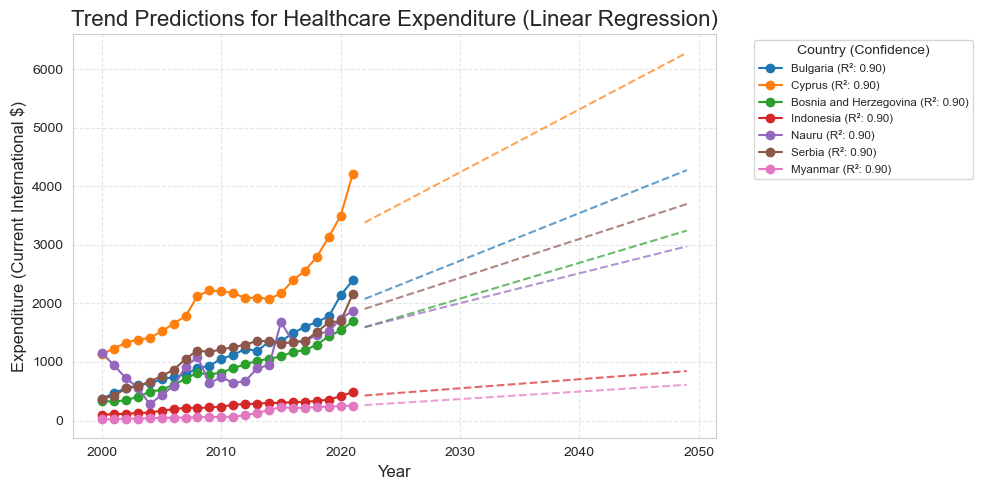

In [62]:
#Continuing with the dataset I have already cleaned at the begining
df_trends.dropna()

future_years = np.array(range(2022, 2050)).reshape(-1, 1)
predictions_list = []

plt.figure(figsize=(10, 5))

# For each country, training a model and predicting
for country in selected_countries:
    country_data = df_trends[df_trends['country'] == country]
    if country_data.empty: continue
    
    X = country_data[['Year']].values
    y = country_data['current healthcare expenditure'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred_train = model.predict(X)
    r2_expenditure = r2_score(y, y_pred_train)
    
    y_pred = model.predict(future_years)
    # Historical data
    line = plt.plot(country_data['Year'], country_data['current healthcare expenditure'], 
                    marker='o', label=f'{country} (R²: {r2:.2f})')
    color = line[0].get_color()
    # Plot predictions
    plt.plot(range(2022, 2050), y_pred, linestyle='--', color=color, alpha=0.7)
    
    for yr, val in zip(range(2022, 2050), y_pred):
        predictions_list.append({'country': country, 'Year': yr, 'predicted_expenditure': val, 'r2_score': r2})

plt.title('Trend Predictions for Healthcare Expenditure (Linear Regression)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Expenditure (Current International $)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Country (Confidence)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

df_predictions = pd.DataFrame(predictions_list)
df_predictions.to_csv('healthcare_expenditure_predictions.csv', index=False)

In [63]:
r2_expenditure

0.8833609844369733

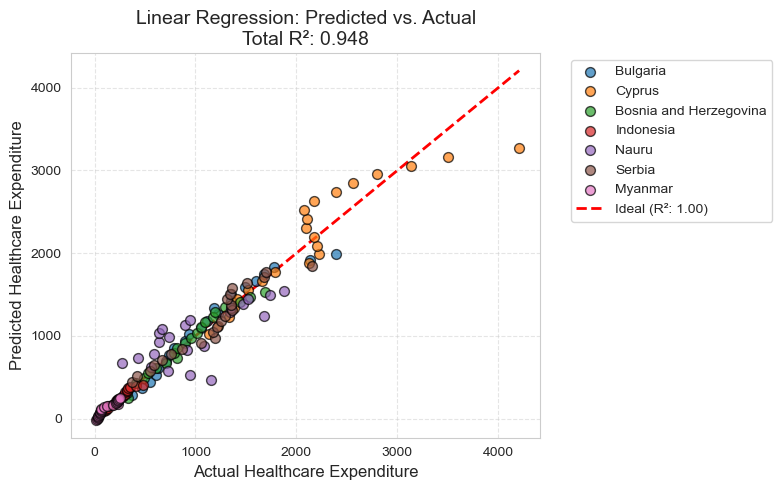

In [ ]:
#Plotting the associated R2 value and best fit line
df_trends_clean = df_trends.dropna(subset=['current healthcare expenditure'])

plt.figure(figsize=(8, 5))

all_actual = []
all_predicted = []

for country in selected_countries:
    country_data = df_trends_clean[df_trends_clean['country'] == country]
    if country_data.empty: continue
    
    X = country_data[['Year']].values
    y = country_data['current healthcare expenditure'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    all_actual.extend(y)
    all_predicted.extend(y_pred)
    
    plt.scatter(y, y_pred, alpha=0.7, s=50, edgecolors='black', label=country, zorder=3)

total_r2 = r2_score(all_actual, all_predicted)

limits = [min(min(all_actual), min(all_predicted)), max(max(all_actual), max(all_predicted))]
plt.plot(limits, limits, color='red', linestyle='--', linewidth=2, label=f'Ideal (R²: 1.00)', zorder=2)

plt.title(f'Linear Regression: Predicted vs. Actual\nTotal R²: {total_r2:.3f}', fontsize=14)
plt.xlabel('Actual Healthcare Expenditure', fontsize=12)
plt.ylabel('Predicted Healthcare Expenditure', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()